# Домашнее задание "Алгоритмы кластеризации"

**Описание задания**

Вам предоставлен [датасет](https://www.kaggle.com/datasets/ghnshymsaini/customer-segmentation-based-on-spending-behavior/data) `Customer Personality Analysis`, содержащий информацию о:
* доходе клиентов
* покупках разных категорий
* активности
* отклике на маркетинг

Ваша задача — выделить сегменты клиентов, используя методы кластеризации.

**Описание датасета**

В этом задании используется датасет `Customer Personality Analysis`, содержащий информацию о клиентах компании и их поведении.
Датасет помогает анализировать характеристики клиентов, их покупательскую активность и реакцию на маркетинговые кампании. На основе этих данных можно выделять группы клиентов (сегменты) и лучше понимать их поведение.

## 1. Загрузка и первичный анализ данных

1. Загрузите датасет
2. Выберите числовые признаки для кластеризации, например:
    * Income
    * Recency
    * траты (Mnt*)
    * покупки (Num*)
3. Проверьте:
    * пропуски
    * распределения признаков
    * выбросы
4. Постройте `scatter plot` по 2 признакам

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
    )
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
df = pd.read_csv(
    'Customer Segmentation_Based_on_Spending_Behavior.csv',
    sep='\t'
    )

pd.set_option('display.max_columns', None)
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [4]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [5]:
print('Процент пропусков в данных')
df.isna().mean()*100

Процент пропусков в данных


,0
ID,0.000000
Year_Birth,0.000000
Education,0.000000
Marital_Status,0.000000
Income,1.071429
Kidhome,0.000000
Teenhome,0.000000
Dt_Customer,0.000000
Recency,0.000000
MntWines,0.000000


In [6]:
# проверка на дубликаты
df.duplicated().sum()

np.int64(0)

Полных дубликатов строк не обнаружено. В признаке `Income` есть пропуски, заполним их медианой

In [7]:
# заполнение пропусков
df['Income'] = df['Income'].fillna(df['Income'].median())

df.isna().sum().sum()

np.int64(0)

In [8]:
# формирование списка признаков для кластеризации

# формирование признака общих трат
df['TotalSpending'] = (
    df['MntWines']
    + df['MntFruits']
    + df['MntMeatProducts']
    + df['MntFishProducts']
    + df['MntSweetProducts']
    + df['MntGoldProds']
    )

# формирование признака общего количества покупок через разные каналы
df['TotalPurchases'] = (
    df['NumWebPurchases']
    + df['NumCatalogPurchases']
    + df['NumStorePurchases']
    )

# список признаков для кластеризации
features = [
    'Income',
    'Recency',
    'TotalSpending',
    'TotalPurchases',
    'NumWebVisitsMonth',
    'NumDealsPurchases'
]

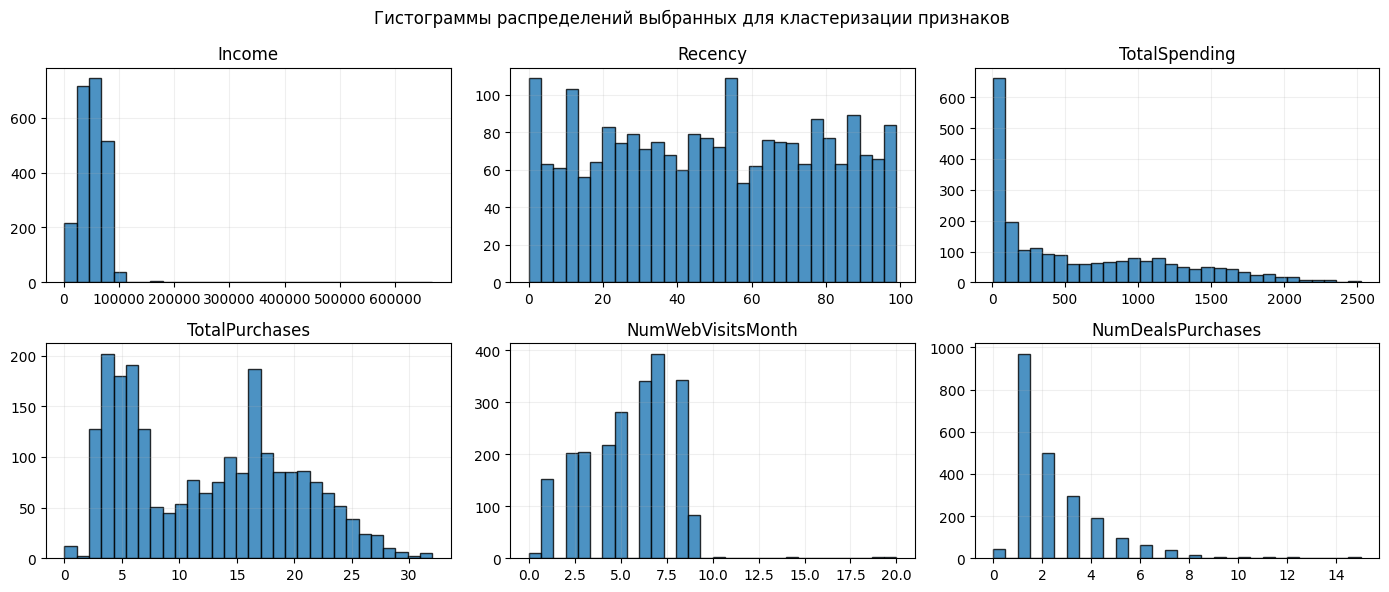

In [9]:
# визуализация распределений выбранных признаков
fig, axes = plt.subplots(2, 3, figsize=(14,6))

for ax, feature in zip(axes.flat, features):
    ax.hist(df[feature], bins=30, edgecolor='black', alpha=0.8)
    ax.set_title(feature)
    ax.grid(alpha=0.2)

plt.suptitle('Гистограммы распределений выбранных для кластеризации признаков ')

plt.tight_layout()
plt.show()

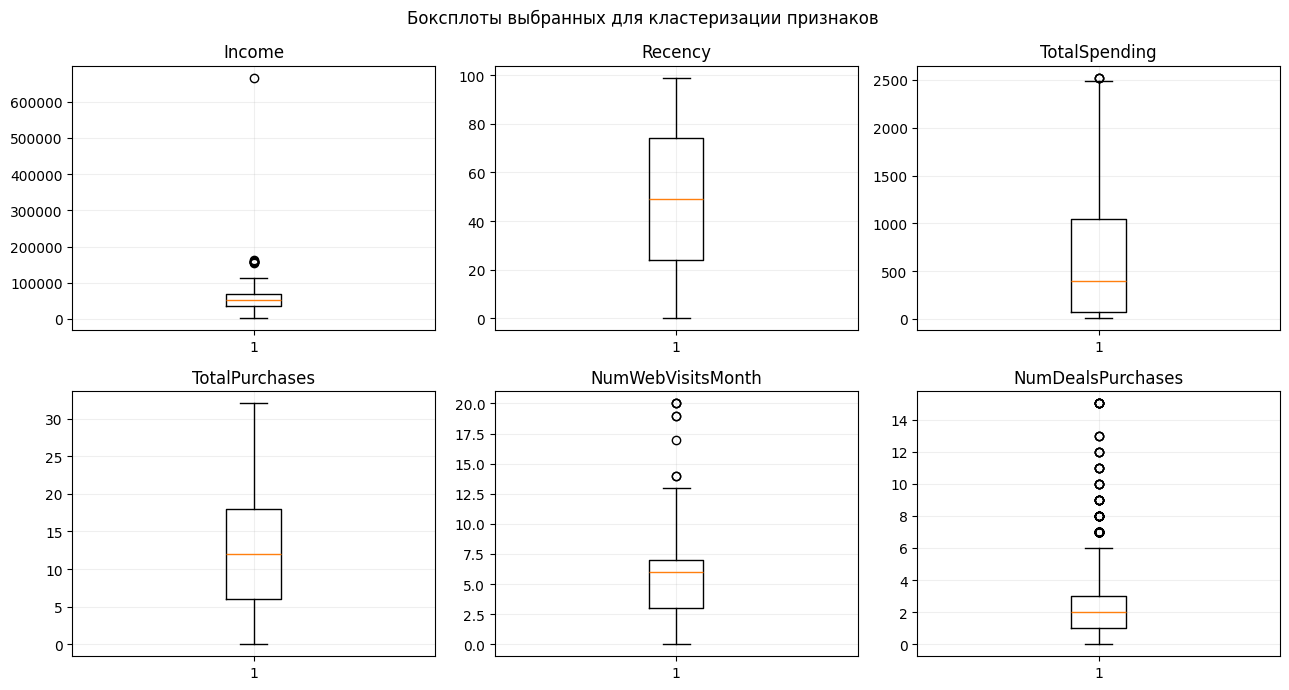

In [10]:
# проверка наличия выбросов в выбранных признаках
fig, axes = plt.subplots(2, 3, figsize=(13,7))

for ax, feature in zip(axes.flat, features):
    ax.boxplot(df[feature], vert=True)
    ax.set_title(feature)
    ax.grid(alpha=0.2)

plt.suptitle('Боксплоты выбранных для кластеризации признаков ')

plt.tight_layout()
plt.show()

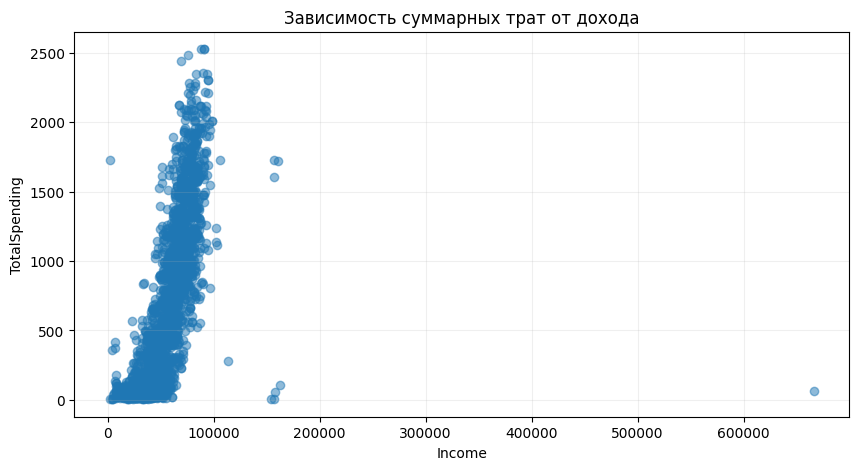

In [11]:
# визуализация зависимости суммарных трат от дохода
plt.figure(figsize=(10, 5))
plt.scatter(df['Income'], df['TotalSpending'], alpha=0.5)

plt.title('Зависимость суммарных трат от дохода')
plt.xlabel('Income')
plt.ylabel('TotalSpending')
plt.grid(alpha=0.2)

plt.show()

In [12]:
df[df['Income'] > 600000]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,TotalSpending,TotalPurchases
2233,9432,1977,Graduation,Together,666666.0,1,0,02-06-2013,23,9,14,18,8,1,12,4,3,1,3,6,0,0,0,0,0,0,3,11,0,62,7


In [13]:
# удаление экстремального значения Income
df = df[df['Income'] <= 600000].copy()

In [14]:
df.shape

(2239, 31)

Для кластеризации были выбраны признаки `Income`, `Recency`, `TotalSpending`, `TotalPurchases`, `NumWebVisitsMonth` и `NumDealsPurchases`. Признаки `TotalSpending` и `TotalPurchases` были сформированы суммированием соответственно исходных показателей трат на разные группы товаров и покупок по разным каналам. Это было сделано для того, чтобы не перегружать модель несколькими близкими по смыслу признаками. Пропуски присутствовали только в `Income`, и они заполнены медианой, так как она менее чувствительна к выбросам, чем среднее значение. Анализ распределений и боксплотов показал наличие потенциальных выбросов, однако большинство из них могут отражать реальное поведение клиентов и поэтому были сохранены. Удалена только одна экстремальная запись с `Income` около `650000`, потому что она очень сильно удалена от основной массы наблюдений и может существенно повлиять на результаты кластеризации. На `scatter plot` по `Income` и `TotalSpending` видна положительная связь между доходом и суммарными тратами клиентов.

## 2. Масштабирование данных

1. Примените `StandardScaler`
2. Обоснуйте выбор признаков для масштабирования. Пропишите ответ в текстовой ячейке ноутбука

In [15]:
# масштабирование
scaler = StandardScaler()

X_scaled = pd.DataFrame(
    scaler.fit_transform(df[features]),
    columns=features,
    index=df.index
    )

X_scaled

,Income,Recency,TotalSpending,TotalPurchases,NumWebVisitsMonth,NumDealsPurchases
0,0.288446,0.306624,1.678944,1.313081,0.693887,0.349782
1,-0.262524,-0.384051,-0.961639,-1.185257,-0.130311,-0.167840
2,0.917946,-0.798456,0.282258,1.035488,-0.542410,-0.685461
3,-1.182738,-0.798456,-0.918460,-0.907664,0.281788,-0.167840
4,0.295687,1.549838,-0.305645,0.202709,-0.130311,1.385025
...,...,...,...,...,...,...
2235,0.432565,-0.107781,1.220579,0.480302,-0.130311,-0.167840
2236,0.562950,0.237556,-0.269109,0.341505,0.693887,2.420268
2237,0.234396,1.446237,1.054505,0.757895,0.281788,-0.685461
2238,0.807322,-1.420063,0.393528,1.174285,-0.954509,-0.167840


In [16]:
# проверка результатов масштабирования
display(X_scaled.mean())
display(X_scaled.std())

,0
Income,-6.505639e-17
Recency,3.411494e-17
TotalSpending,3.490831e-17
TotalPurchases,4.918898e-17
NumWebVisitsMonth,1.872355e-16
NumDealsPurchases,-7.933706e-18


,0
Income,1.000223
Recency,1.000223
TotalSpending,1.000223
TotalPurchases,1.000223
NumWebVisitsMonth,1.000223
NumDealsPurchases,1.000223


Для масштабирования выбраны все признаки, используемые в кластеризации: `Income`, `Recency`, `TotalSpending`, `TotalPurchases`, `NumWebVisitsMonth` и `NumDealsPurchases`. Они имеют существенно разные масштабы измерения: например, доход клиента принимает значения в десятках тысяч, а количество покупок и посещений сайта измеряется единицами. Так как алгоритмы кластеризации основаны на расстояниях между объектами, признаки с большими числовыми значениями без масштабирования могли бы оказывать непропорционально сильное влияние на результат.

## 3. KMeans кластеризация

1. Примените `KMeans`
2. Попробуйте значения `k` от 2 до 10
3. Для каждого `k` визуализируйте кластеры на двумерной проекции

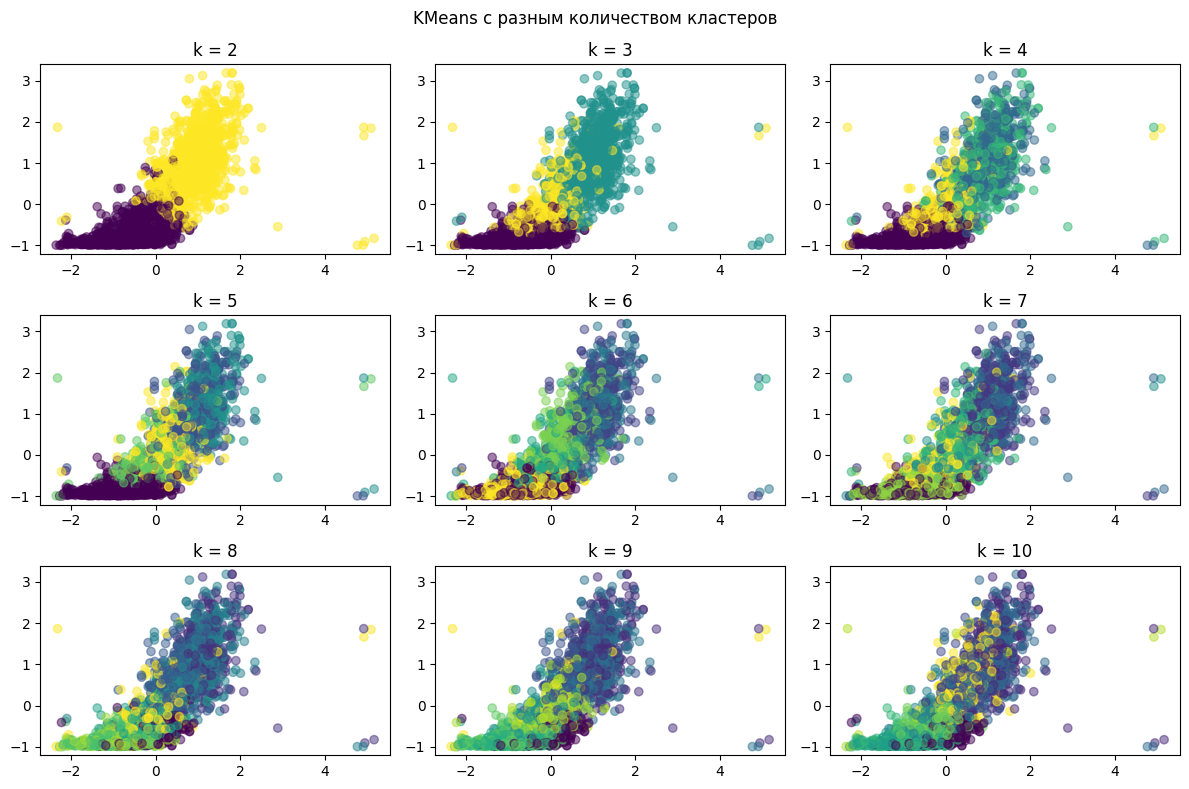

In [17]:
# кластеризация с разными значениями k
k_values = list(range(2, 11))

plt.figure(figsize=(12,8))

for i, k in enumerate(k_values):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)

    plt.subplot(3, 3, i+1)
    # для двумерной проекции используем признаки Income и TotalSpending
    plt.scatter(
        X_scaled['Income'],
        X_scaled['TotalSpending'],
        c=labels,
        cmap='viridis',
        alpha=0.5
        )
    plt.title(f'k = {k}')

plt.suptitle('KMeans с разным количеством кластеров')
plt.tight_layout()
plt.show()

По графикам можно увидеть, что при `k=2-3` разделение выглядит достаточно выраженным и наиболее понятным, а начиная с `k=4` и выше пространство дробится все сильнее, и кластеры начинают существенно перекрываться. То есть, визуально значения `k=2-3` выглядят оптимальными, но выбор можно будет сделать только после реализации метода локтя и получения значений метрик `Silhouette Score`, `Davies-Bouldin` и `Calinski-Harabasz`.

## 4. Метод локтя (Elbow Method)

1. Постройте график `inertia` от `k`
2. Определите оптимальное количество кластеров

Ищем точку перегиба — после неё улучшение качества замедляется



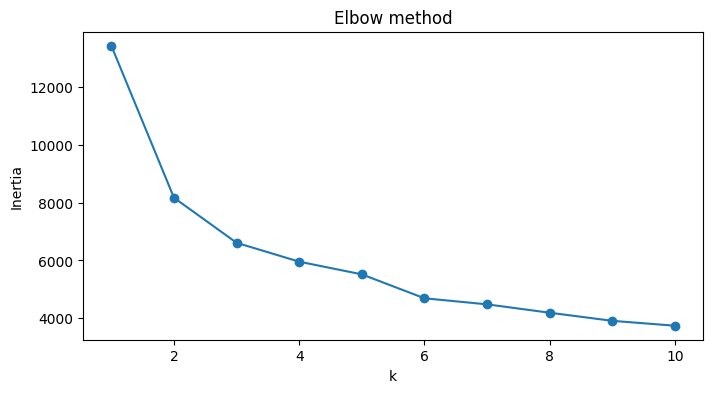

In [18]:
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

print('Ищем точку перегиба — после неё улучшение качества замедляется\n')

plt.figure(figsize=(8,4))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow method')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.show()

Оптимальное количество кластеров по методу локтя примерно `k=3`, поскольку после этого значения уменьшение `inertia` заметно замедляется.

## 5. Silhouette Score

1. Рассчитайте `silhouette score` для разных `k`
2. Постройте `silhouette plot` для оптимального `k` (график `bar chart`)

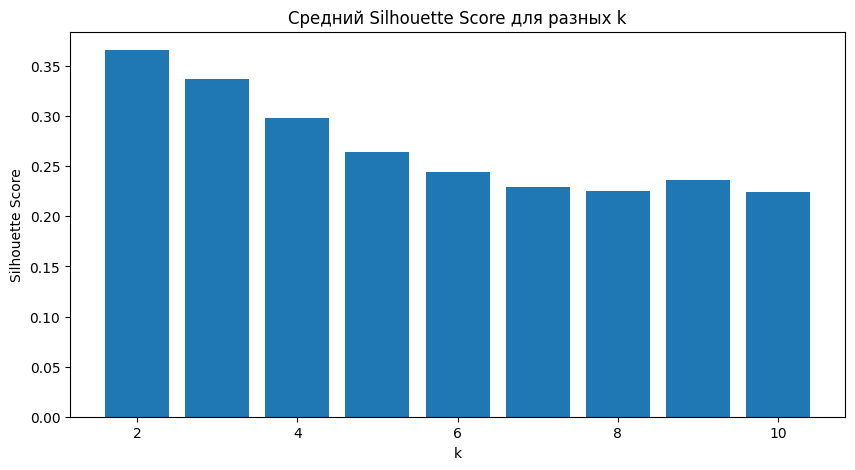

In [19]:
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(10,5))

plt.bar(k_values, silhouette_scores)

plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('Средний Silhouette Score для разных k')

plt.show()

По значению `Silhouette Score` оптимальное количество кластеров: `k=2`

## 6. Метрики качества

1. Для разных `k` рассчитайте:
    * `Davies-Bouldin`
    * `Calinski-Harabasz`
2. Сравните результаты всех методов (`Elbow`, `Silhouette` и метрики) и выберите одно оптимальное значение `k`, которое лучше всего подходит по совокупности критериев

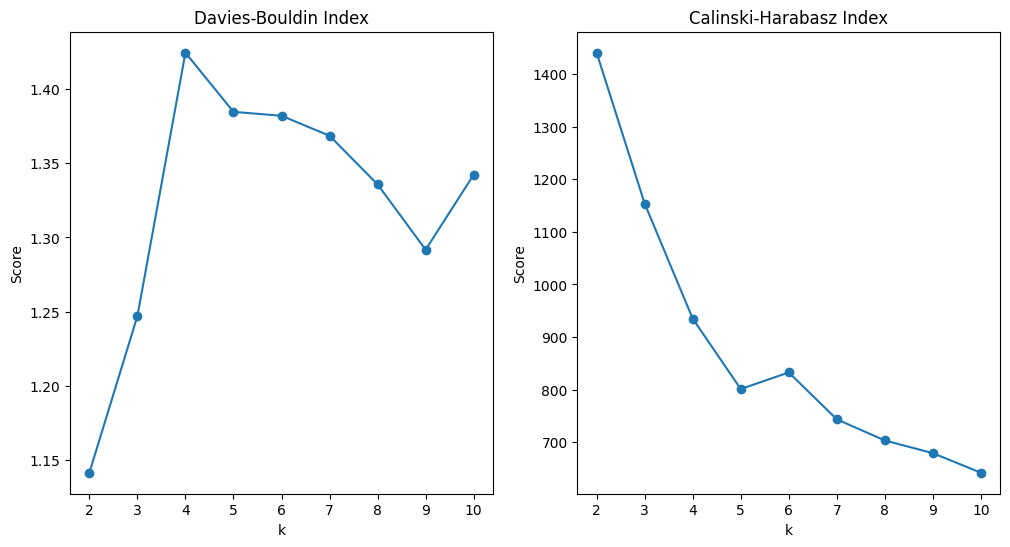

In [20]:
db_scores = []
ch_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)

    db_scores.append(davies_bouldin_score(X_scaled, labels))
    ch_scores.append(calinski_harabasz_score(X_scaled, labels))

plt.figure(figsize=(12,6))

plt.subplot(1, 2, 1)
plt.plot(k_values, db_scores, marker='o')
plt.title('Davies-Bouldin Index')
plt.xlabel('k')
plt.ylabel('Score')

plt.subplot(1, 2, 2)
plt.plot(k_values, ch_scores, marker='o')
plt.title('Calinski-Harabasz Index')
plt.xlabel('k')
plt.ylabel('Score')

plt.show()

Результаты всех реализованных методов.
* Elbow method: k=3
* Silhouette Score: k=2;
* Davies-Bouldin: k=2;
* Calinski-Harabasz: k=2.

По совокупности критериев оптимальным выбрано `k=2`

In [21]:
# предсказания при выбранном количестве кластеров k=2 для дальнейшего сравнения методов
kmeans = KMeans(n_clusters=2, random_state=42)
labels_kmeans = kmeans.fit_predict(X_scaled)

## 7. DBSCAN

1. Подберите параметры: `eps` и `min_samples`
2. Постройте визуализацию
3. Определите оптимальное количество кластеров
4. Ответьте на вопрос: «как значения параметров влияют на результат кластеризации?». Пропишите ответ в текстовой ячейке ноутбука

*При оценке качества кластеризации DBSCAN шумовые точки с меткой -1 исключаются из расчёта внутренних метрик, поскольку они не относятся ни к одному кластеру. Количество шумовых точек учитывается отдельно при подборе параметров и отображается на визуализации..*

In [22]:
# подбор параметров eps и min_samples

eps_values = [0.3, 0.5, 0.7, 1.0]
min_samples_values = [3, 5, 7, 10]

results = []

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)

        # исключение шумовых точек для корректного расчета метрик
        mask = labels != -1

        if n_clusters > 1:
            results.append({
                'eps': eps,
                'min_samples': min_samples,
                'clusters': n_clusters,
                'noise': n_noise,
                'silhouette': silhouette_score(X_scaled[mask], labels[mask]),
                'davies_bouldin': davies_bouldin_score(X_scaled[mask], labels[mask]),
                'calinski_harabasz': calinski_harabasz_score(X_scaled[mask], labels[mask])
                })

results_df = pd.DataFrame(results)
display(results_df)

,eps,min_samples,clusters,noise,silhouette,davies_bouldin,calinski_harabasz
0,0.3,3,104,1705,0.422157,0.690591,225.651726
1,0.3,5,27,2027,0.416709,0.807437,148.578094
2,0.3,7,9,2144,0.445574,0.855302,201.968134
3,0.5,3,99,887,-0.046536,1.041729,46.404446
4,0.5,5,35,1268,-0.044684,1.197856,87.302049
5,0.5,7,12,1493,-0.063758,1.631827,123.537134
6,0.5,10,6,1684,0.032342,2.057390,129.966923
7,0.7,3,20,267,-0.275045,1.109824,6.946618
8,0.7,5,10,384,-0.170001,1.123717,7.547706
9,0.7,10,7,725,0.162807,1.235549,331.437157


По совокупности критериев наиболее сбалансированным выбором параметров `DBSCAN` являются: `eps=1.0`, `min_samples=7`. При таких параметрах получено:
* 2 кластера
* всего 93 шумовые точки из 2239
* достаточно высокий `Silhouette Score = 0.357` и низкий `Davies-Bouldin = 0.639`

Комбинации с меньшим `eps` дают большое количество мелких кластеров и слишком много шумовых точек, поэтому для интерпретации они менее удобны

Таким образом, оптимальное количество кластеров = 2.



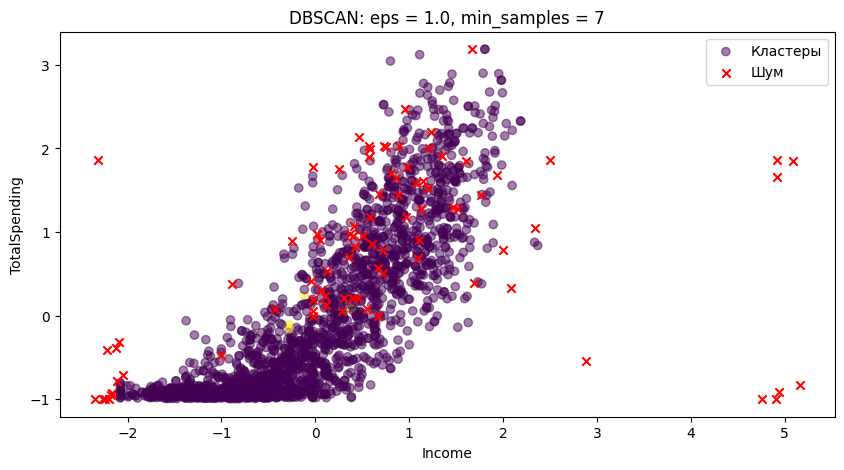

In [23]:
# реализация DBSCAN с подобранными параметрами и визуализация результата реализации

dbscan = DBSCAN(eps=1.0, min_samples=7)
labels_dbscan = dbscan.fit_predict(X_scaled)

# маски для кластеров и шума
cluster_mask = labels_dbscan != -1
noise_mask = labels_dbscan == -1

plt.figure(figsize=(10,5))

# точки, отнесенные к кластерам
plt.scatter(
    X_scaled.loc[cluster_mask, 'Income'],
    X_scaled.loc[cluster_mask, 'TotalSpending'],
    c=labels_dbscan[cluster_mask],
    cmap='viridis',
    alpha=0.5,
    label='Кластеры'
    )

# шумовые точки
plt.scatter(
    X_scaled.loc[noise_mask, 'Income'],
    X_scaled.loc[noise_mask, 'TotalSpending'],
    c='red',
    marker='x',
    label='Шум'
    )

plt.title('DBSCAN: eps = 1.0, min_samples = 7')
plt.xlabel('Income')
plt.ylabel('TotalSpending')
plt.legend()
plt.show()

`DBSCAN` при выбранных параметрах выделил 2 кластера и небольшое количество шумовых точек. Однако на двумерной проекции по `Income` и `TotalSpending` кластеры разделяются хуже, чем у `KMeans`, а часть шумовых наблюдений расположена внутри основной области данных. Это указывает на то, что структура данных не очень хорошо соответствует плотностному принципу `DBSCAN` при выбранных параметрах.

Параметр `eps` задаёт максимальное расстояние, в пределах которого точки считаются соседними. При слишком маленьком `eps` образуется большое количество мелких кластеров и значительная часть объектов определяется как шум. При увеличении `eps` соседних точек становится больше, кластеры укрупняются, их количество уменьшается, а число шумовых точек обычно сокращается.

Параметр `min_samples` задаёт минимальное количество соседних точек, необходимое для формирования плотной области. При небольшом `min_samples` алгоритм легче формирует кластеры, поэтому их может быть больше. При увеличении `min_samples` требования к плотности становятся строже, часть небольших групп перестаёт считаться кластерами, а число шумовых точек может увеличиваться.

Таким образом, результат `DBSCAN` существенно зависит от сочетания `eps` и `min_samples`: слишком малые значения могут приводить к сильному дроблению данных и большому количеству шума, а слишком большие — к объединению разных групп в один крупный кластер.

## 8. Иерархическая кластеризация

1. Постройте дендрограмму
2. Определите число кластеров
3. Примените `AgglomerativeClustering`

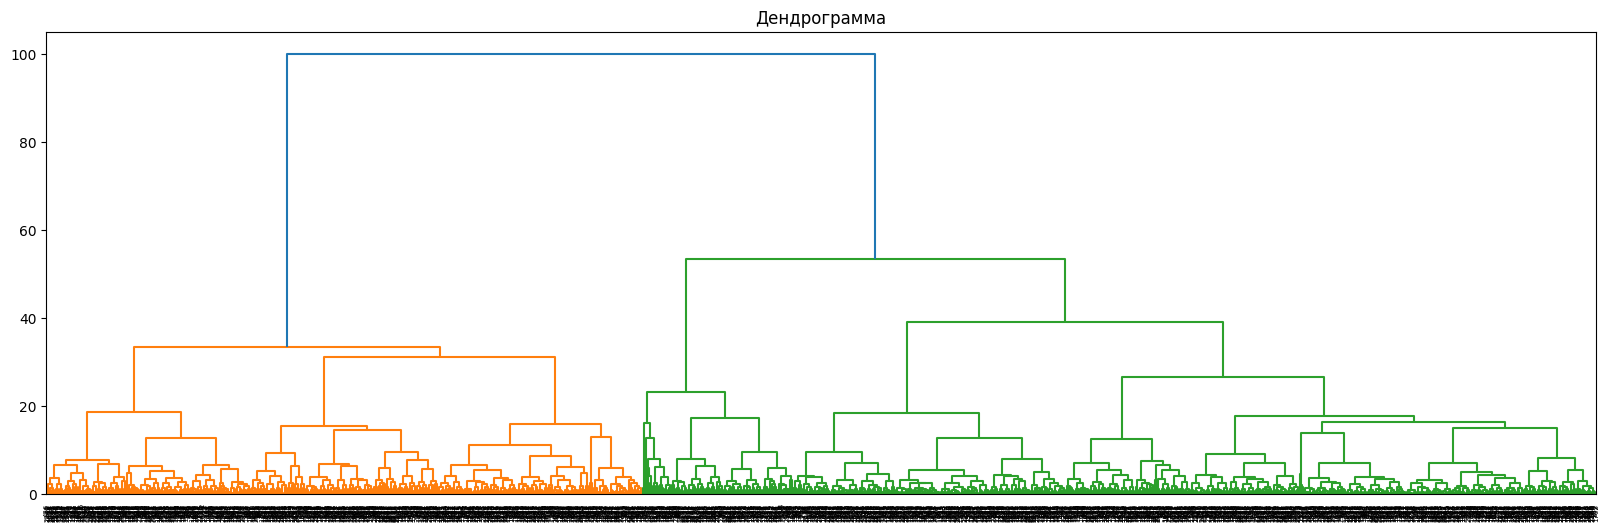

In [24]:
# построение дендрограммы

linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(20,6))
dendrogram(linked)
plt.title('Дендрограмма')
plt.show()

На дендрограмме наиболее заметный скачок наблюдается перед последним объединением двух крупных ветвей. Поэтому дерево целесообразно разрезать между уровнями примерно 55 и 100. Такой разрез даёт 2 кластера.

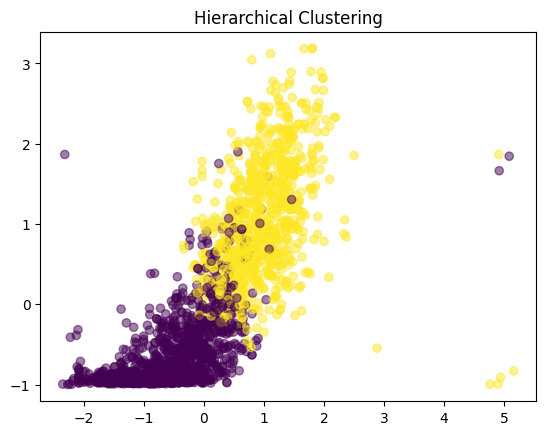

In [25]:
# реализация AgglomerativeClustering и визуализация результата реализации

agg = AgglomerativeClustering(n_clusters=2)
labels_agg = agg.fit_predict(X_scaled)

plt.scatter(
    X_scaled['Income'],
    X_scaled['TotalSpending'],
    c=labels_agg,
    cmap='viridis',
    alpha=0.5
    )
plt.title('Hierarchical Clustering')
plt.show()

## 9. Интерпретация кластеров (ключевой этап)

1. Выберите алгоритм кластеризации, который показал наилучший результат по метрикам и визуализации
2. Добавьте полученные метки кластеров в исходный датафрейм
3. Для каждого кластера:
    * рассчитайте средние значения всех признаков, использованных в кластеризации
    * при необходимости визуализируйте различия (например, с помощью bar chart или boxplot)
4. Сравните кластеры между собой:
    * какие признаки различаются сильнее всего?
    * есть ли кластеры с экстремальными (очень высокими или низкими) значениями?
    * какие группы клиентов можно выделить по поведению?
    
    Пример:
    * «клиенты с высоким доходом и высокими тратами»
    * «редкие покупатели с низкой активностью»
    * «активные клиенты со средним доходом»

In [26]:
# сравнение метрик реализованных метрик
def evaluate_metrics(X, labels):
    if len(set(labels)) < 2:
        return {
            'Silhouette': np.nan,
            'Davies-Bouldin': np.nan,
            'Calinski-Harabasz': np.nan
        }

    return {
        'Silhouette': silhouette_score(X, labels),
        'Davies-Bouldin': davies_bouldin_score(X, labels),
        'Calinski-Harabasz': calinski_harabasz_score(X, labels)
    }

# для DBSCAN исключаем шумовые точки с меткой -1
dbscan_mask = labels_dbscan != -1

scaled_metrics_df = pd.DataFrame({
    'KMeans': evaluate_metrics(X_scaled, labels_kmeans),
    'DBSCAN': evaluate_metrics(X_scaled[dbscan_mask], labels_dbscan[dbscan_mask]),
    'Hierarchical': evaluate_metrics(X_scaled, labels_agg)
})

display(scaled_metrics_df)

,KMeans,DBSCAN,Hierarchical
Silhouette,0.365992,0.357322,0.351745
Davies-Bouldin,1.141648,0.638705,1.160420
Calinski-Harabasz,1440.728219,14.428582,1326.023725


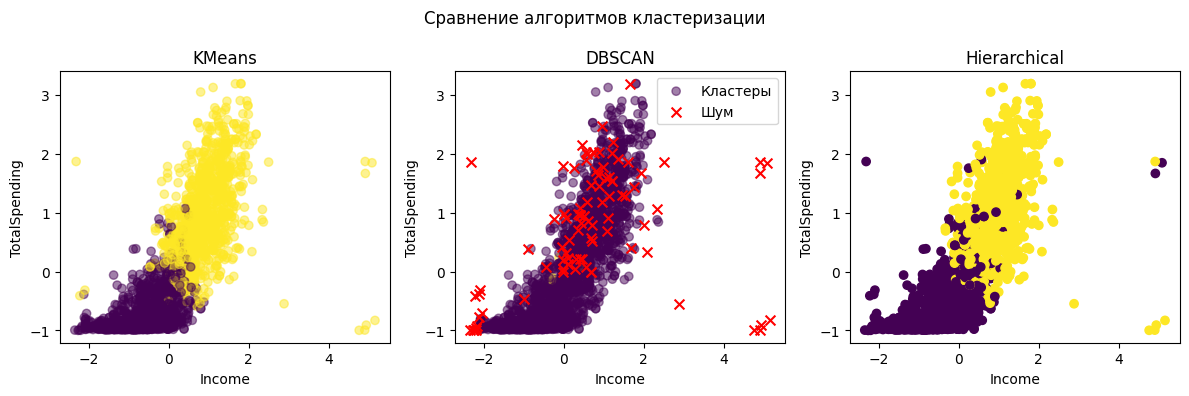

In [27]:
# визуальное сравнение результатов работы методов

plt.figure(figsize=(12, 4))

# KMeans
plt.subplot(1, 3, 1)
plt.scatter(
    X_scaled['Income'],
    X_scaled['TotalSpending'],
    c=labels_kmeans,
    cmap='viridis',
    alpha=0.5
    )
plt.title("KMeans")
plt.xlabel('Income')
plt.ylabel('TotalSpending')

# DBSCAN
plt.subplot(1, 3, 2)

# маски для кластеров и шума
cluster_mask = labels_dbscan != -1
noise_mask = labels_dbscan == -1

# точки, отнесенные к кластерам
plt.scatter(
    X_scaled.loc[cluster_mask, 'Income'],
    X_scaled.loc[cluster_mask, 'TotalSpending'],
    c=labels_dbscan[cluster_mask],
    cmap='viridis',
    alpha=0.5,
    label='Кластеры'
    )
# шумовые точки
plt.scatter(
    X_scaled.loc[noise_mask, 'Income'],
    X_scaled.loc[noise_mask, 'TotalSpending'],
    c='red',
    marker='x',
    s=50,
    label='Шум'
    )
plt.title("DBSCAN")
plt.xlabel('Income')
plt.ylabel('TotalSpending')
plt.legend()

# Hierarchical
plt.subplot(1, 3, 3)
plt.scatter(
    X_scaled['Income'],
    X_scaled['TotalSpending'],
    c=labels_agg,
    cmap='viridis'
    )
plt.title("Hierarchical")
plt.xlabel('Income')
plt.ylabel('TotalSpending')

plt.suptitle("Сравнение алгоритмов кластеризации")
plt.tight_layout()
plt.show()

Для DBSCAN внутренние метрики рассчитаны только по точкам, отнесённым к кластерам; 93 шумовых наблюдения с меткой -1 исключены из расчёта, учитываются и показаны отдельно на визуализации.

По результатам сравнения `KMeans` имеет максимальные значения `Silhouette Score` и `Calinski-Harabasz Index`. `DBSCAN` показывает минимальное значение `Davies-Bouldin Index`, однако эта метрика рассчитана только для объектов, отнесённых к кластерам, без шумовых точек. Иерархическая кластеризация показывает результаты, близкие к `KMeans`.

Визуально результаты `KMeans` и иерархической кластеризации похожи, оба метода достаточно чётко разделяют клиентов на две основные группы по сочетанию `Income` и `TotalSpending`, при этом у кластеры выглядят более компактными и интерпретируемыми. `DBSCAN` показывает менее удачное разделение: группы сильнее перекрываются.

С учётом совокупности метрик, визуальной разделимости, отсутствия исключённых наблюдений и удобства интерпретации для дальнейшего анализа выбран `KMeans` с `k=2`.

In [28]:
# добавляем полученные с помощью KMeans метки кластеров в исходный датафрейм
df['cluster'] = labels_kmeans

# средние значения всех признаков, использованных в кластеризации
cluster_means = df.groupby('cluster')[features].mean()
display(cluster_means)

,Income,Recency,TotalSpending,TotalPurchases,NumWebVisitsMonth,NumDealsPurchases
cluster,,,,,,
0,37527.210628,48.573313,175.151280,7.502715,6.550039,2.581846
1,71551.394211,49.864211,1190.690526,19.373684,3.642105,1.974737


In [29]:
# размеры кластеров
df['cluster'].value_counts().sort_index()

,count
cluster,
0,1289
1,950


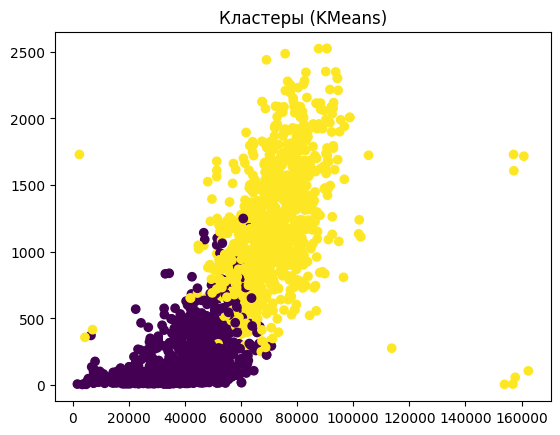

In [30]:
# визуализация кластеров
plt.scatter(df['Income'], df['TotalSpending'], c=df['cluster'], cmap='viridis')
plt.title("Кластеры (KMeans)")
plt.show()

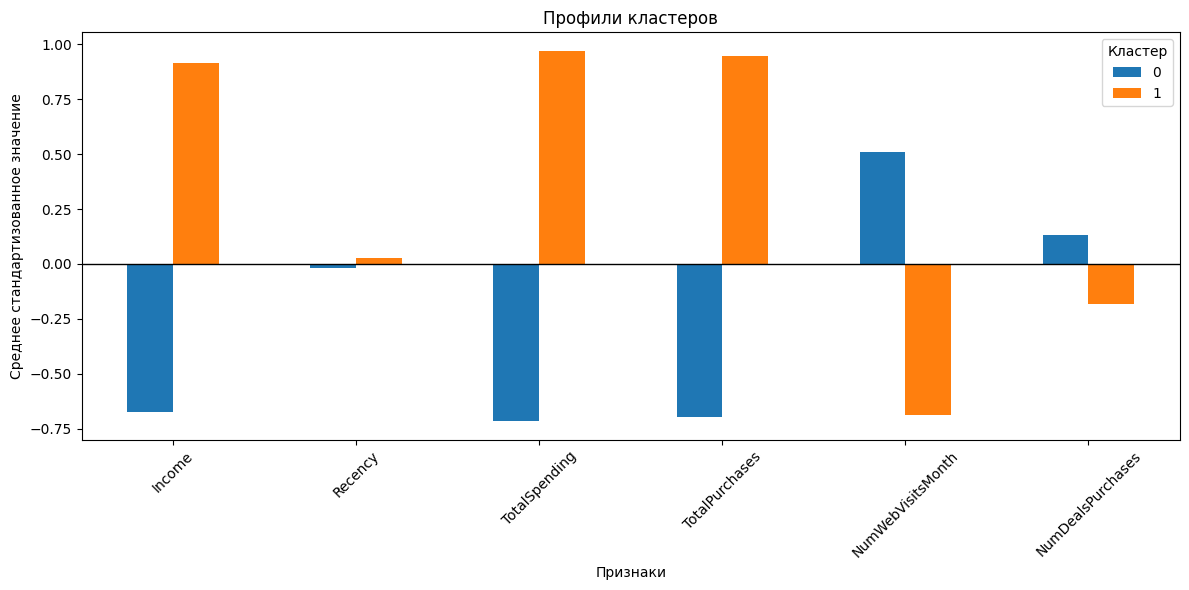

In [31]:
# визуальное сравнение с использованием стандартизованных данных
# так как величины признаков существенно различаются

X_scaled_with_cluster = X_scaled.copy()
X_scaled_with_cluster['cluster'] = labels_kmeans

cluster_profiles = X_scaled_with_cluster.groupby('cluster').mean()

cluster_profiles.T.plot(kind='bar', figsize=(12,6))

plt.axhline(0, color='black', linewidth=1)
plt.title('Профили кластеров')
plt.xlabel('Признаки')
plt.ylabel('Среднее стандартизованное значение')
plt.xticks(rotation=45)
plt.legend(title='Кластер')
plt.tight_layout()
plt.show()

In [32]:
display(cluster_profiles)

,Income,Recency,TotalSpending,TotalPurchases,NumWebVisitsMonth,NumDealsPurchases
cluster,,,,,,
0,-0.674410,-0.018915,-0.715598,-0.699092,0.508458,0.133336
1,0.915068,0.025665,0.970953,0.948557,-0.689898,-0.180917


In [33]:
# таблица признаков с различиями между кластерами
feature_differences_df = pd.DataFrame({
    'cluster 0': cluster_profiles.loc[0],
    'cluster 1': cluster_profiles.loc[1],
    'difference': (cluster_profiles.loc[0] - cluster_profiles.loc[1]).abs()
    }).sort_values('difference', ascending=False)

display(feature_differences_df)

,cluster 0,cluster 1,difference
TotalSpending,-0.715598,0.970953,1.686551
TotalPurchases,-0.699092,0.948557,1.647650
Income,-0.674410,0.915068,1.589478
NumWebVisitsMonth,0.508458,-0.689898,1.198356
NumDealsPurchases,0.133336,-0.180917,0.314253
Recency,-0.018915,0.025665,0.044580


В результате кластеризации методом `KMeans` с `k=2` было выделено две группы клиентов: 1289 наблюдений в кластере 0 и 950 наблюдений в кластере 1.

Наиболее сильные различия между кластерами наблюдаются по признакам `TotalSpending`, `TotalPurchases` и `Income`. Также заметно различается `NumWebVisitsMonth`. При этом `Recency` практически не различается между кластерами, поэтому этот признак слабо влияет на их разделение.

**Кластер 0** характеризуется более низкими значениями дохода `Income`, суммарных трат и покупок `TotalSpending` и `TotalPurchases`. При этом клиенты этого кластера чаще посещают сайт (`NumWebVisitsMonth`) и немного чаще совершают покупки по акциям (`NumDealsPurchases`). Эту группу можно интерпретировать как ***клиентов с более низким доходом и низкой покупательской активностью, но более частыми посещениями сайта***.

**Кластер 1** характеризуется заметно более высокими значениями дохода `Income`, суммарных трат и покупок `TotalSpending` и `TotalPurchases`. При этом такие клиенты реже посещают сайт (`NumWebVisitsMonth`) и немного реже используют скидочные предложениям (`NumDealsPurchases`). Эту группу можно интерпретировать ***как обеспеченных и активных покупателей с высокими расходами***.

Наиболее выраженные высокие значения наблюдаются у **кластера 1** по `Income`, `TotalSpending` и `TotalPurchases`, тогда как у **кластера 0** заметно выше `NumWebVisitsMonth`. По `Recency` экстремальных различий между кластерами нет.

Таким образом, основное разделение клиентов происходит по уровню дохода, объёму расходов и общей покупательской активности. **Кластер 1** представляет более ценную с точки зрения покупок группу клиентов, тогда как **кластер 0** отличается более низкими расходами при более высокой активности посещения сайта.

## 10. Сравнение алгоритмов

1. Сравните результаты кластеризации, полученные с помощью `KMeans`, `DBSCAN` и `Hierarchical`, по следующим критериям:
    * качество кластеризации (по метрикам: `Silhouette`, `Davies-Bouldin`, `Calinski-Harabasz`)
    * форма и разделимость кластеров (по визуализации)
2. Зафиксируйте выводы в ноутбуке (в виде текстовых ячеек):
    * какой алгоритм показал наилучший результат для данного датасета
    * в чём преимущества и недостатки каждого метода
    * почему выбранный алгоритм является наиболее подходящим в этой задаче
3. Сформулируйте краткий итоговый вывод по сравнению алгоритмов

    *По желанию: сравните результаты кластеризации до и после масштабирования. Сделайте вывод, как масштабирование влияет на качество кластеров и работу алгоритмов.

In [34]:
# сравнение метрик реализованных методов

display(scaled_metrics_df)

,KMeans,DBSCAN,Hierarchical
Silhouette,0.365992,0.357322,0.351745
Davies-Bouldin,1.141648,0.638705,1.160420
Calinski-Harabasz,1440.728219,14.428582,1326.023725


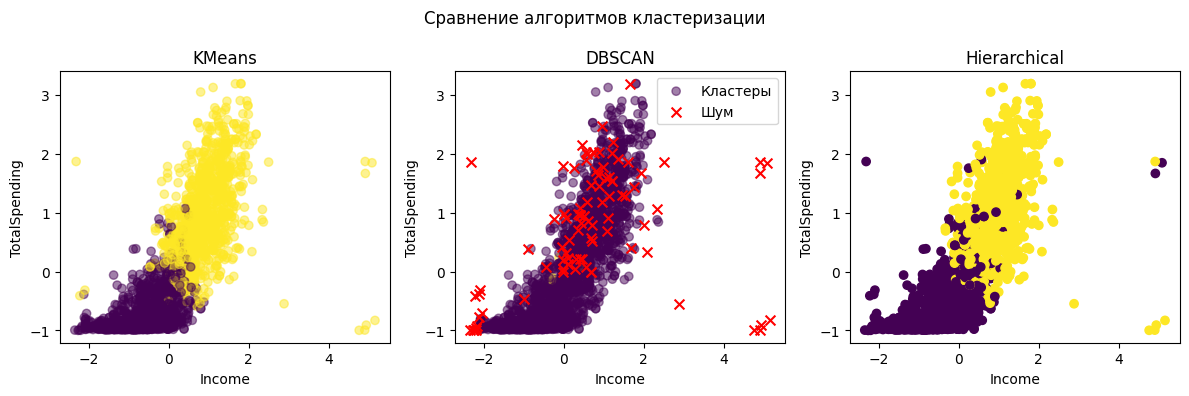

In [35]:
# визуальное сравнение результатов работы методов

plt.figure(figsize=(12, 4))

# KMeans
plt.subplot(1, 3, 1)
plt.scatter(
    X_scaled['Income'],
    X_scaled['TotalSpending'],
    c=labels_kmeans,
    cmap='viridis',
    alpha=0.5
    )
plt.title("KMeans")
plt.xlabel('Income')
plt.ylabel('TotalSpending')

# DBSCAN
plt.subplot(1, 3, 2)

# маски для кластеров и шума
cluster_mask = labels_dbscan != -1
noise_mask = labels_dbscan == -1

# точки, отнесенные к кластерам
plt.scatter(
    X_scaled.loc[cluster_mask, 'Income'],
    X_scaled.loc[cluster_mask, 'TotalSpending'],
    c=labels_dbscan[cluster_mask],
    cmap='viridis',
    alpha=0.5,
    label='Кластеры'
    )
# шумовые точки
plt.scatter(
    X_scaled.loc[noise_mask, 'Income'],
    X_scaled.loc[noise_mask, 'TotalSpending'],
    c='red',
    marker='x',
    s=50,
    label='Шум'
    )
plt.title("DBSCAN")
plt.xlabel('Income')
plt.ylabel('TotalSpending')
plt.legend()

# Hierarchical
plt.subplot(1, 3, 3)
plt.scatter(
    X_scaled['Income'],
    X_scaled['TotalSpending'],
    c=labels_agg,
    cmap='viridis'
    )
plt.title("Hierarchical")
plt.xlabel('Income')
plt.ylabel('TotalSpending')

plt.suptitle("Сравнение алгоритмов кластеризации")
plt.tight_layout()
plt.show()

*Для дополнительного визуального анализа построена двумерная `PCA-проекция`. В отличие от визуализации по `Income` и `TotalSpending`, главные компоненты формируются на основе всех признаков, использованных в кластеризации, поэтому такая проекция позволяет оценить разделимость кластеров с учётом многомерной структуры данных.*

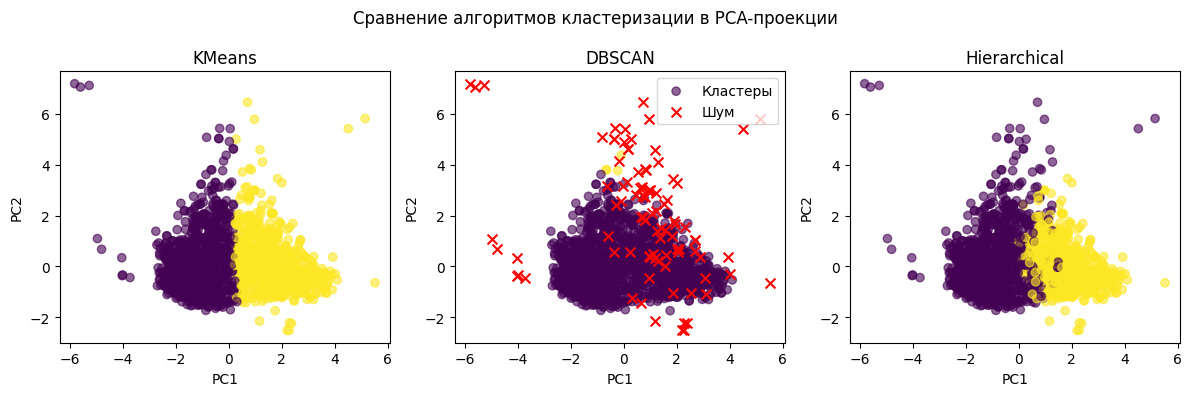

In [38]:
# двумерная PCA-проекция всех признаков, использованных в кластеризации

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 4))

# KMeans
plt.subplot(1, 3, 1)
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels_kmeans,
    cmap='viridis',
    alpha=0.6
)
plt.title('KMeans')
plt.xlabel('PC1')
plt.ylabel('PC2')

# DBSCAN
plt.subplot(1, 3, 2)

cluster_mask = labels_dbscan != -1
noise_mask = labels_dbscan == -1

plt.scatter(
    X_pca[cluster_mask, 0],
    X_pca[cluster_mask, 1],
    c=labels_dbscan[cluster_mask],
    cmap='viridis',
    alpha=0.6,
    label='Кластеры'
)

plt.scatter(
    X_pca[noise_mask, 0],
    X_pca[noise_mask, 1],
    c='red',
    marker='x',
    s=50,
    label='Шум'
)

plt.title('DBSCAN')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()

# Hierarchical
plt.subplot(1, 3, 3)
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels_agg,
    cmap='viridis',
    alpha=0.6
)
plt.title('Hierarchical')
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.suptitle('Сравнение алгоритмов кластеризации в PCA-проекции')
plt.tight_layout()
plt.show()

In [39]:
print(
    'Доля объяснённой дисперсии двумя компонентами:',
    pca.explained_variance_ratio_.sum()
)

Доля объяснённой дисперсии двумя компонентами: 0.6986174692354925


`KMeans` показал максимальные `Silhouette Score = 0.366` и `Calinski-Harabasz Index = 1440.73`. `DBSCAN` получил минимальный `Davies-Bouldin Index = 0.639`, однако его метрики рассчитаны только по объектам, вошедшим в кластеры, тогда как 93 шумовые точки исключены из оценки. Иерархическая кластеризация по значениям метрик близка к `KMeans`.

По визуализации видно, что `KMeans` формирует две достаточно компактные и хорошо разделимые группы, хотя в смежной области и наблюдается некоторое пересечение. `Hierarchical Clustering` дает похожую структуру, но немного уступает `KMeans` по всем трем метрикам. `DBSCAN` показывает менее чёткое разделение: группы сильнее смешиваются, а часть объектов определяется как шум.

`KMeans` преимущества - простота, высокая скорость, понятная интерпретация и хорошая работа с компактными кластерами; недостатки - необходимость заранее задавать число кластеров и чувствительность к выбросам и форме кластеров.

`DBSCAN` преимущества - не требует заранее задавать число кластеров, способен находить кластеры сложной формы и выделять шум; недостатки - результат сильно зависит от значений параметров `eps` (радиус вокруг точки) и `min_samples` (минимальное количество точек внутри радиуса), сложности при различной плотности данных.

`Hierarchical Clustering`: преимущества - позволяет исследовать структуру данных с помощью дендрограммы и на её основе обосновать выбор числа кластеров; недостатки - более высокая вычислительная сложность и меньшая пригодность для больших наборов данных.

Таким образом, для данной задачи наиболее подходит `KMeans`: он показал лучшие значения двух метрик из трех, достаточно хорошо разделил данные на две интерпретируемые группы и оказался наиболее удобным для дальнейшей сегментации клиентов.


Для дополнительного визуального анализа использована `PCA-проекция` по всем признакам, участвовавшим в кластеризации. Первые две главные компоненты объясняют около `69.9%` общей дисперсии данных.

В `PCA-пространстве` `KMeans` формирует две достаточно компактные и хорошо разделимые группы. Иерархическая кластеризация показывает близкий результат, но граница между кластерами несколько менее выражена. Для `DBSCAN` наблюдается более сильное перекрытие групп, а часть объектов определяется как шум.

Таким образом, `PCA-визуализация` подтверждает результаты метрик и предыдущего визуального анализа: для данного датасета наиболее интерпретируемое и устойчивое разделение даёт `KMeans`.

In [36]:
# сравнение результатов кластеризации до и после масштабирования

X_unscaled = df[features]

# KMean
kmeans_unscaled = KMeans(n_clusters=2, random_state=42)
labels_kmeans_unscaled = kmeans_unscaled.fit_predict(X_unscaled)

# DBSCAN
dbscan_unscaled = DBSCAN(eps=1.0, min_samples=7)
labels_dbscan_unscaled = dbscan_unscaled.fit_predict(X_unscaled)
# исключаем шумовые точки с меткой -1
dbscan_unscaled_mask = labels_dbscan_unscaled != -1

# Hierarchical
agg_unscaled = AgglomerativeClustering(n_clusters=2)
labels_agg_unscaled = agg_unscaled.fit_predict(X_unscaled)

# метрики до масштабирования
unscaled_metrics_df = pd.DataFrame({
    'KMeans': evaluate_metrics(X_unscaled, labels_kmeans_unscaled),
    'DBSCAN': evaluate_metrics(
        X_unscaled[dbscan_unscaled_mask],
        labels_dbscan_unscaled[dbscan_unscaled_mask]
        ),
    'Hierarchical': evaluate_metrics(X_unscaled, labels_agg_unscaled)
})

# формирование таблицы сравнения метрик до и после масштабирования
metrics_scaled_unscaled_df = pd.concat(
    {
    'Unscaled': unscaled_metrics_df,
    'Scaled': scaled_metrics_df
    },
    axis=1
    )

display(metrics_scaled_unscaled_df)

Unscaled                           Scaled             \
                        KMeans DBSCAN Hierarchical       KMeans     DBSCAN   
Silhouette            0.598619    NaN     0.598493     0.365992   0.357322   
Davies-Bouldin        0.532710    NaN     0.532351     1.141648   0.638705   
Calinski-Harabasz  4806.223099    NaN  4797.041751  1440.728219  14.428582   

                                
                  Hierarchical  
Silhouette            0.351745  
Davies-Bouldin        1.160420  
Calinski-Harabasz  1326.023725

Без масштабирования значения внутренних метрик для `KMeans` и иерархической кластеризации оказались лучше. Это связано с тем, что признаки `Income` и `TotalSpending`, имеющие значительно больший числовой масштаб, начинают доминировать при расчёте расстояний и сами по себе хорошо разделяют данные на две группы. Однако такое разделение не означает, что немасштабированные данные предпочтительнее: вклад остальных признаков существенно снижается, и результат во многом определяется единицами измерения. После стандартизации все признаки получают сопоставимый вес, поэтому кластеризация учитывает их совместное влияние.

Для `DBSCAN` на немасштабированных данных после исключения шумовых точек не сформировалось как минимум двух кластеров, поэтому внутренние метрики рассчитать невозможно (`NaN`). Это дополнительно демонстрирует высокую чувствительность DBSCAN и параметра eps к масштабу признаков.

При этом абсолютные значения `Silhouette`, `Davies-Bouldin` и `Calinski-Harabasz` до и после масштабирования следует сравнивать осторожно, поскольку они рассчитываются уже в разных геометриях пространства признаков. Поэтому в данном эксперименте важнее не только сами значения метрик, но и то, как масштабирование меняет структуру кластеров и поведение алгоритмов.

## 11. Финальный вывод

Ответьте на вопросы:
* какой алгоритм лучше подходит для этого датасета?
* какое число кластеров оптимально?
* какие сегменты клиентов вы выделили?

Пропишите ответы в текстовой ячейке ноутбука.

* Для данного датасета лучше подходит `KMeans`: он показал максимальные значения `Silhouette Score = 0.366` и `Calinski-Harabasz Index = 1440.73`, обеспечил достаточно чёткое визуальное разделение и сформировал две интерпретируемые группы без исключения наблюдений как шум. Минимальный `Davies-Bouldin Index` получен у `DBSCAN`, однако для этого метода метрики рассчитывались только по объектам, отнесённым к кластерам, без 93 шумовых точек.
* По совокупности рассмотренных критериев оптимальным количеством кластеров для данного датасета является `k=2`.
* Были выделены следующие сегменты клиентов:
    * Кластер 0: клиенты с более низким доходом и низкой покупательской активностью, но более частыми посещениями сайта
    * Кластер 1: обеспеченные и активные клиенты с высокими расходами